# IV/LV Calibration (LvSection method)

Author: Sebastien Gurrieri, sebgur@gmail.com

This notebook illustrates the calibration of a type of Local Vol models where the Local Vol is specified by a series of parametric functions at each expiry. The vanilla options are calculated by forward PDE and the parametric functions are calibrated by optimization on the PDE prices (not Dupire).

In [ ]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import sdevpy as sd
from sdevpy.maths import metrics
from sdevpy.market import eqvolsurface as vsurf
from sdevpy.market.eqforward import get_forward_curves
from sdevpy.utilities import timegrids
from sdevpy.volatility.localvol.lvsection_calib import calibrate_lv_bysections

print("SDevPy version: " + sd.__version__)

SDevPy version: 1.0.5


### Retrieve market data
The SDevPy library has a set of minimalistic market data files containing sample data. Beware that it contains toy data only, to be used strictly for illustration purposes. The data necessary for fitting, which is the expiries, the forwards, the strikes and the volatilities, are all contained in 1 file (per valuation date) and retrieved in an object (dictionary). The user can use the model simply by re-creating that object from their own data.

In [ ]:
name, valdate = "ABC", dt.datetime(2025, 12, 15)

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]

# Retrieve option data
file = vsurf.data_file(name, valdate)
option_data = vsurf.eqvolsurfacedata_from_file(file)
mkt_data = {'option_data': option_data, 'forward_curve': fwd_curve}
print(f"Retrieved market data from file {file}")

# Access data in object
expiries = option_data.expiries
fwds = fwd_curve.value(expiries)
mkt_strikes = option_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
mkt_vols = option_data.vols

# Quick check of size consistency
print(f"Number of expiries: {len(expiries)}")
print(f"Number of forwards: {len(fwds)}")
print(f"Number of strike sections: {len(mkt_strikes)}")
print(f"Number of vol sections: {len(mkt_vols)}")
for i in range(len(expiries)):
    print(f"Expiry {i+1} number of strikes/vols: {len(mkt_strikes[i])}/{len(mkt_vols[i])}")

Retrieved market data from file C:\Code\SDev.Python\datasets\marketdata\eqoptions\ABC\20251215-000000.json
Number of expiries: 6
Number of forwards: 6
Number of strike sections: 6
Number of vol sections: 6
Expiry 1 number of strikes/vols: 5/5
Expiry 2 number of strikes/vols: 5/5
Expiry 3 number of strikes/vols: 5/5
Expiry 4 number of strikes/vols: 5/5
Expiry 5 number of strikes/vols: 5/5
Expiry 6 number of strikes/vols: 5/5


### Fit Local Vol Model
In this section we choose and fit an implied vol model, and then display the accuracy of the fit against the market data.

In [8]:
# Choose model
section_model = 'BiExp' # SVI, CubicVol, BiExp

# Calibration config
# lv_data_folder = lvf.test_data_folder()
config = {'start_new': True, 'model': section_model, 'store_date': valdate, 'optimizer': 'SLSQP',
          'tol': 1e-6, 'pde_timesteps': 50,  'pde_spotsteps': 100, #'lv_folder': lv_data_folder,
          'sol_as_init': False}

# Calibrate LV
print("Launching calibration")
calib_result = calibrate_lv_bysections(valdate, name, config, verbose=True, calc_pde_vols=True)
lv = calib_result['lv']
print(lv)

Launching calibration
Starting from new LV
IV time grid: [0.09863014 0.24931507 0.49863014 1.         2.         5.00273973]
LV time grid: [0.0, np.float64(0.09863013698630137), np.float64(0.2493150684931507), np.float64(0.4986301369863014), np.float64(1.0), np.float64(2.0)]
Val date: 15-Dec-2025
Vol surface information
----------------------------------------------------------------------
----------------------------------------------------------------------
Name: ABC
Valuation date: 15-Dec-2025
Snap date: 15-Dec-2025 00:00:00
Strike input type: absolute
Number of expiries: 6
----------------------------------------------------------------------
Expiry 1/6: 20-Jan-2026
Strikes [ 90.2632  94.7008  99.8876 105.3584 110.5382]
Vols [0.3835 0.3258 0.276  0.2935 0.3268]
----------------------------------------------------------------------
Expiry 2/6: 16-Mar-2026
Strikes [ 84.9586  91.6564  99.7191 108.4912 117.0442]
Vols [0.3385 0.3037 0.276  0.2819 0.3006]
--------------------------------

### Diagnostics
Compare PDE implied vols vs market and look at the shape of the optimum local vols.

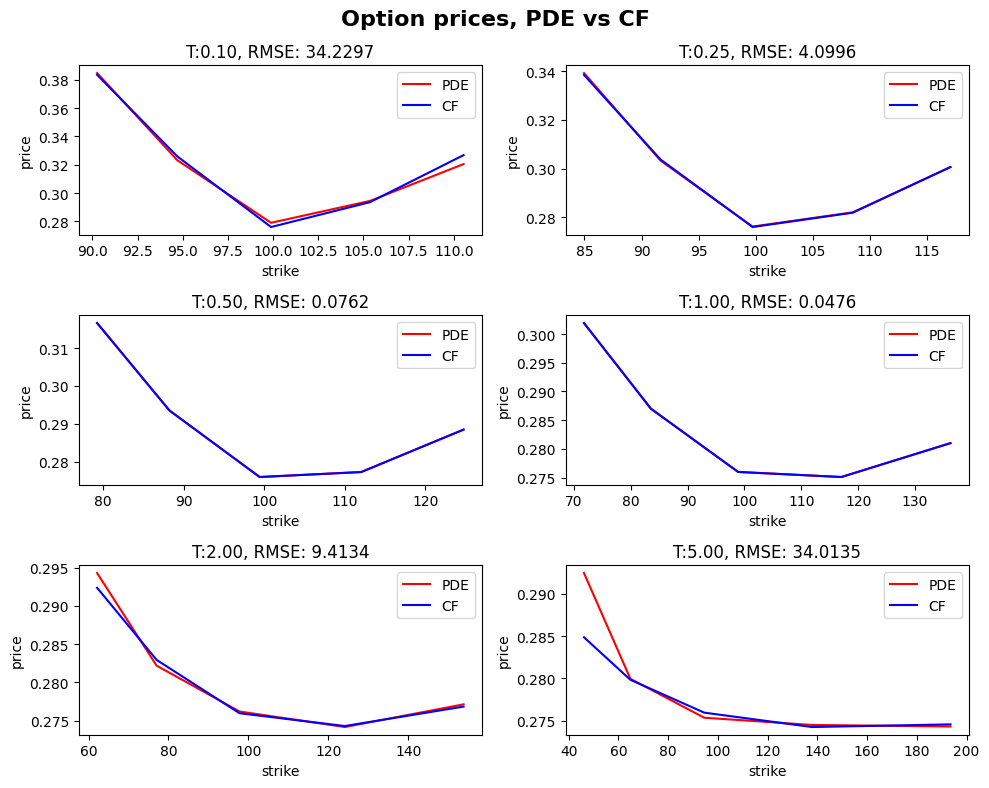

Params at 0.099, [0.23510551 0.97637052 1.         0.05566366 0.62748176 2.        ]
Params at 0.249, [ 0.22262662  0.32172082  0.33963468  0.05493664  0.04127546 -0.79112015]
Params at 0.499, [ 0.23913606  0.27354998  0.3003955   0.08680797  0.04555717 -0.83649718]
Params at 1.000, [ 0.25337287  0.25342981  0.28648996  0.13514571  0.06033593 -0.48268985]
Params at 2.000, [ 0.26343868  0.26363767  0.2811805   0.14077656  0.088363   -0.2093193 ]
Params at 5.003, [0.27175622 0.2718056  0.27190397 0.17983653 0.08796332 0.04475511]


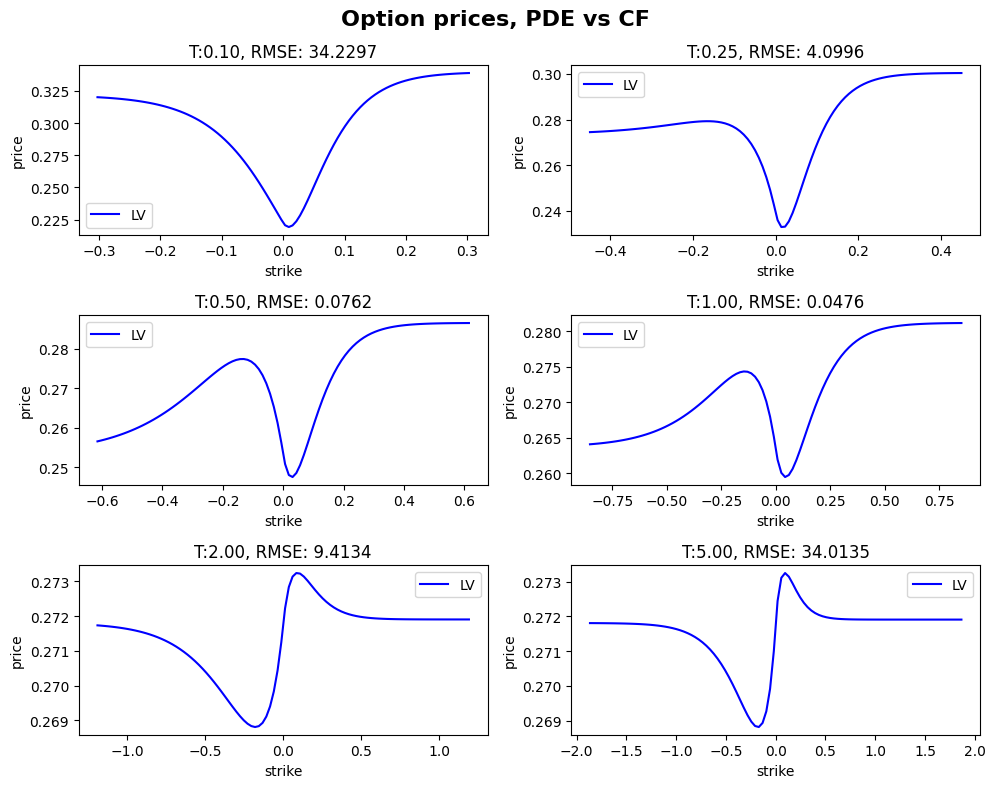

In [9]:
# ################ DIAGNOSTICS ################################################################
# Retrieve results for diagnostics
pde_vols = calib_result['pde_vols']
surface_data = calib_result['iv_data']
expiries = surface_data.expiries
expiry_grid = np.array([timegrids.model_time(valdate, expiry) for expiry in expiries])

# Retrieve forward curve
fwd_curve = get_forward_curves([name], valdate)[0]

# fwds = surface_data.forwards
fwds = fwd_curve.value(expiries)
strike_surface = surface_data.get_strikes(fwd_curve=fwd_curve, to_type='absolute')
vol_surface = surface_data.vols

# Calculate RMSEs on vols
vol_rmses = []
for exp_idx in range(len(expiry_grid)):
    vol_rmses.append(10000.0 * metrics.rmse(vol_surface[exp_idx], pde_vols[exp_idx]))

# Display price results
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        strikes = strike_surface[exp_idx]
        ax.plot(strikes, pde_vols[exp_idx], label="PDE", color='red')
        ax.plot(strikes, vol_surface[exp_idx], label="CF", color='blue')
        ax.set_title(f"T:{expiry_grid[exp_idx]:.2f}, RMSE: {vol_rmses[exp_idx]:.4f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('price')
        ax.legend()

fig.suptitle('Option prices, PDE vs CF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Display LV results
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))
for i in range(n_rows):
    for j in range(n_cols):
        ax = axes[i, j]
        exp_idx = n_cols * i + j
        expiry = expiry_grid[exp_idx]
        vol = vol_surface[exp_idx].mean()
        stdev = vol * np.sqrt(expiry)
        print(f"Params at {expiry:.3f}, {lv.params(exp_idx)}")
        xs = np.linspace(-3.0 * stdev, 3.0 * stdev, 100)
        lvs = lv.value(expiry, xs)
        ax.plot(xs, lvs, label="LV", color='blue')
        # strikes = strike_surface[exp_idx]
        # lvs = lv.value(expiry_grid[exp_idx], np.log(strikes / fwds[exp_idx]))
        # ax.plot(strikes, lvs, label="LV", color='blue')
        ax.set_title(f"T:{expiry:.2f}, RMSE: {vol_rmses[exp_idx]:.4f}")
        ax.set_xlabel('strike')
        ax.set_ylabel('price')
        ax.legend()

fig.suptitle('Option prices, PDE vs CF', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
